In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense,Flatten

warnings.filterwarnings("ignore")
ln= LabelEncoder()

In [2]:
data = pd.read_csv("forestfires (1).csv")
data

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep,size_category
0,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,0,0,0,0,1,0,0,0,0,small
1,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,0,0,0,0,0,0,0,1,0,small
2,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,0,0,0,0,0,0,0,1,0,small
3,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,0,0,0,0,1,0,0,0,0,small
4,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,0,0,0,0,1,0,0,0,0,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,...,0,0,0,0,0,0,0,0,0,large
513,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,...,0,0,0,0,0,0,0,0,0,large
514,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,...,0,0,0,0,0,0,0,0,0,large
515,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,...,0,0,0,0,0,0,0,0,0,small


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   month          517 non-null    object 
 1   day            517 non-null    object 
 2   FFMC           517 non-null    float64
 3   DMC            517 non-null    float64
 4   DC             517 non-null    float64
 5   ISI            517 non-null    float64
 6   temp           517 non-null    float64
 7   RH             517 non-null    int64  
 8   wind           517 non-null    float64
 9   rain           517 non-null    float64
 10  area           517 non-null    float64
 11  dayfri         517 non-null    int64  
 12  daymon         517 non-null    int64  
 13  daysat         517 non-null    int64  
 14  daysun         517 non-null    int64  
 15  daythu         517 non-null    int64  
 16  daytue         517 non-null    int64  
 17  daywed         517 non-null    int64  
 18  monthapr  

In [4]:
data.shape

(517, 31)

In [5]:
data.isna().sum()

month            0
day              0
FFMC             0
DMC              0
DC               0
ISI              0
temp             0
RH               0
wind             0
rain             0
area             0
dayfri           0
daymon           0
daysat           0
daysun           0
daythu           0
daytue           0
daywed           0
monthapr         0
monthaug         0
monthdec         0
monthfeb         0
monthjan         0
monthjul         0
monthjun         0
monthmar         0
monthmay         0
monthnov         0
monthoct         0
monthsep         0
size_category    0
dtype: int64

ValueError: could not convert string to float: 'mar'

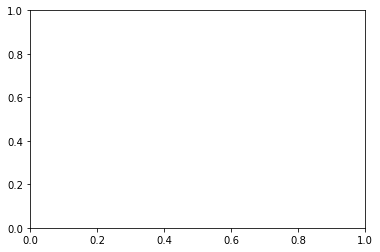

In [9]:
sns.distplot(data)

In [10]:
data.month = ln.fit_transform(data.month)
data.day = ln.fit_transform(data.day)
data.size_category = ln.fit_transform(data.size_category)

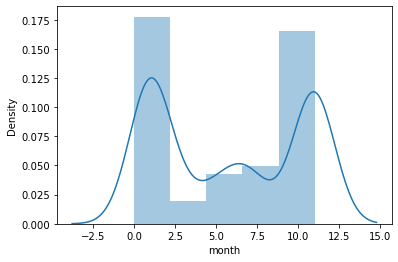

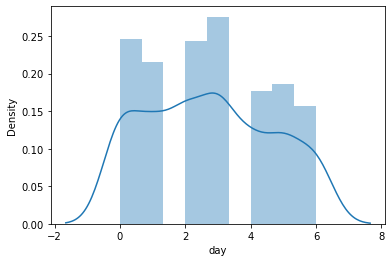

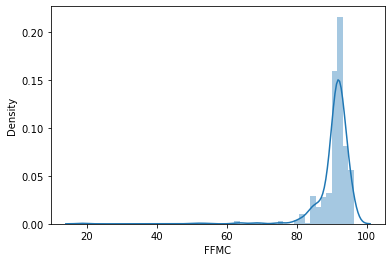

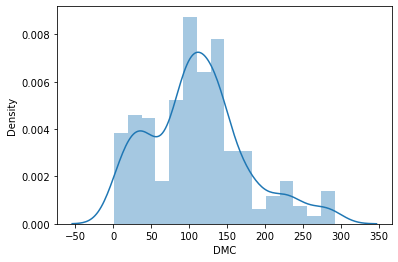

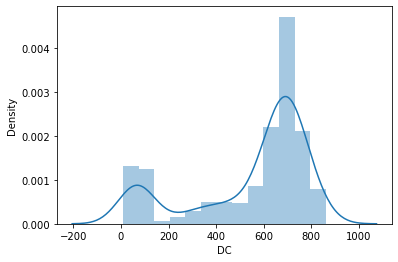

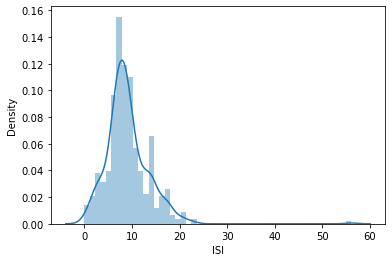

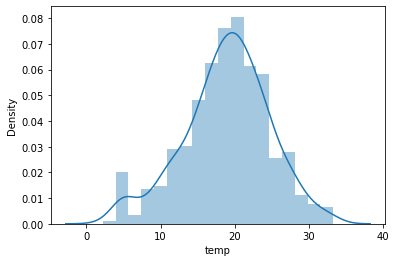

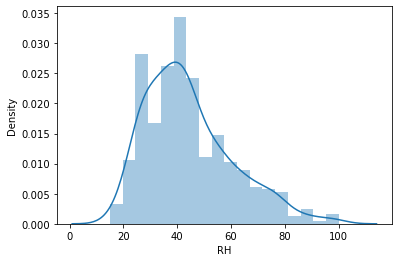

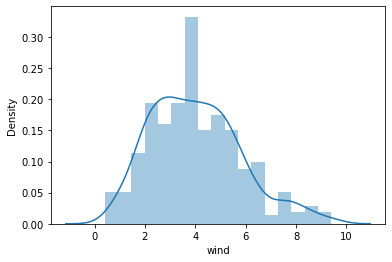

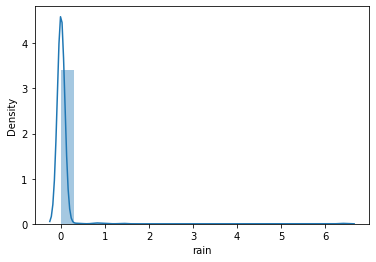

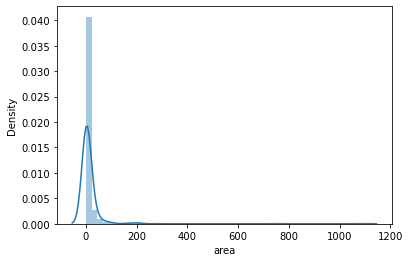

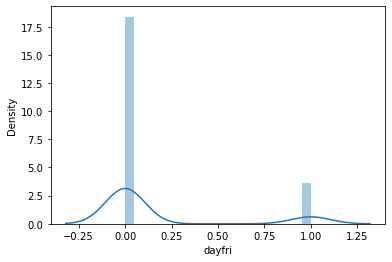

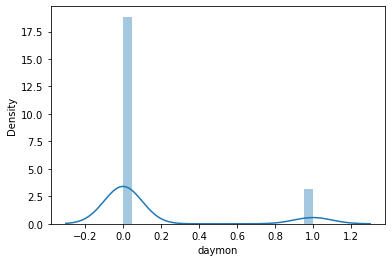

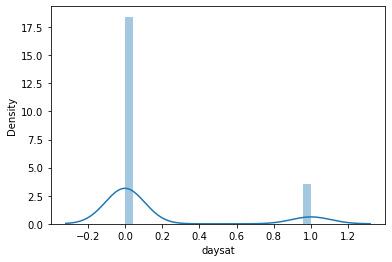

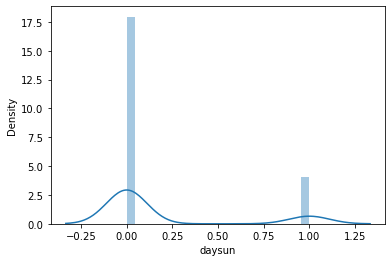

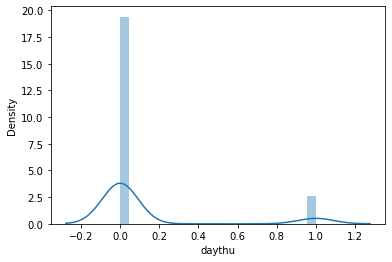

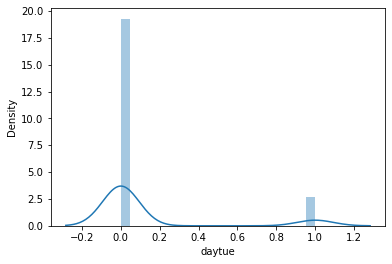

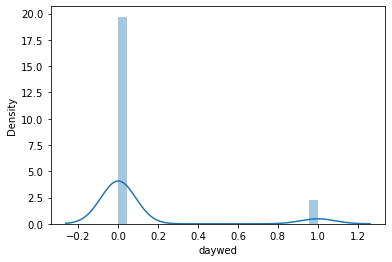

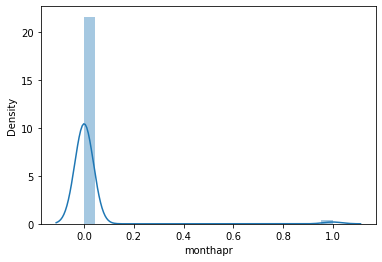

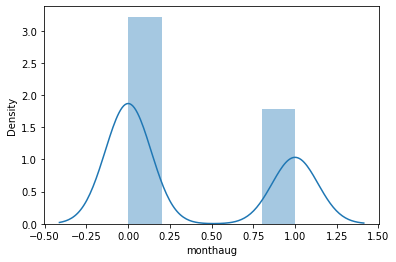

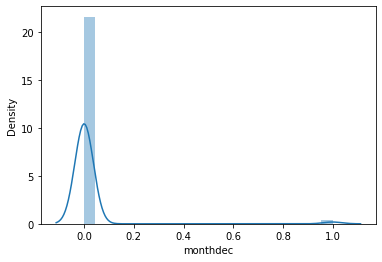

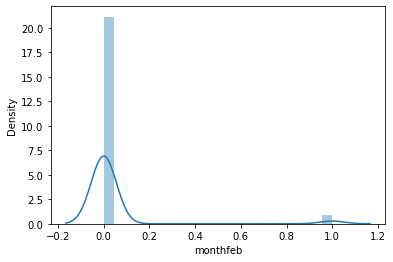

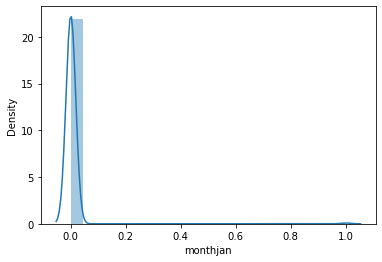

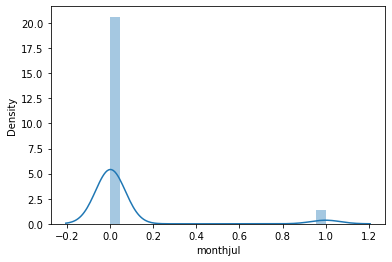

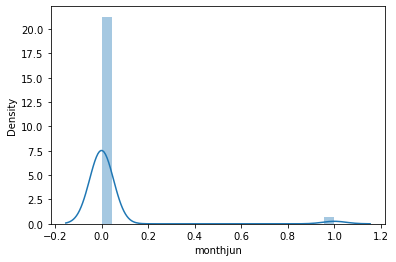

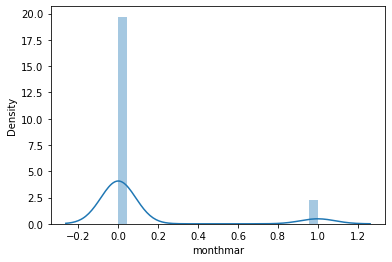

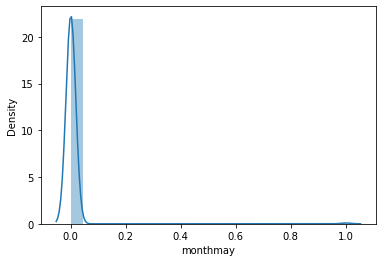

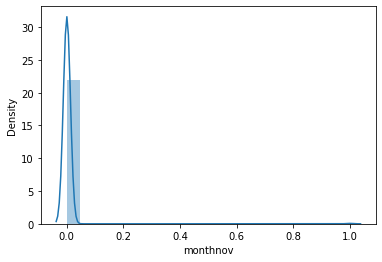

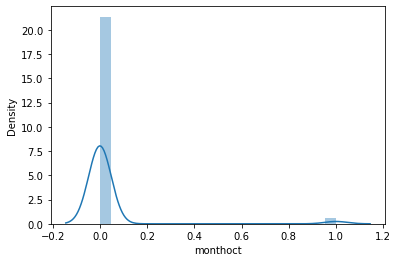

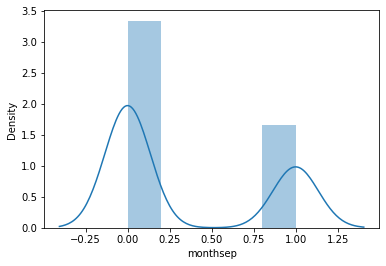

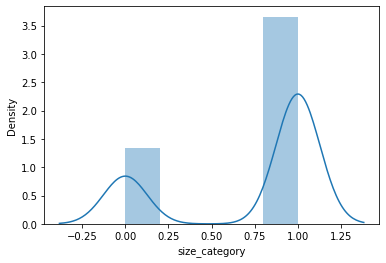

In [13]:
a = data.columns
for i in range (0,len(a)):
    sns.distplot(data[a[i]])
    plt.show()

In [70]:
data.head(1)

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep,size_category
0,7,0,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,0,0,0,0,1,0,0,0,0,1


<AxesSubplot:>

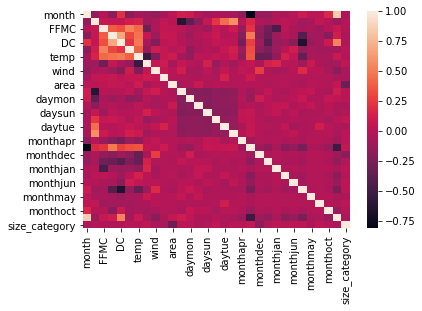

In [72]:
sns.heatmap(data.corr())

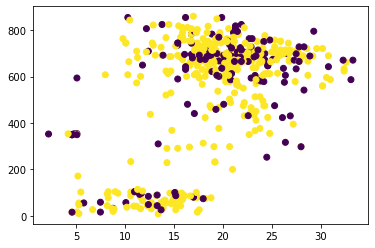

In [71]:
plt.scatter(data.temp,data.DC,c = data.size_category)

In [15]:
x = data.drop(labels="size_category",axis=1)
y = data[["size_category"]]

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=12)

In [104]:
model = Sequential()
model.add(Flatten(input_dim = 30))
model.add(Dense(100,activation = "relu"))
model.add(Dense(1,activation = "sigmoid"))

model.summary()

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_15 (Flatten)        (None, 30)                0         
                                                                 
 dense_32 (Dense)            (None, 100)               3100      
                                                                 
 dense_33 (Dense)            (None, 1)                 101       
                                                                 
Total params: 3,201
Trainable params: 3,201
Non-trainable params: 0
_________________________________________________________________


In [105]:
model.compile(optimizer ='adam',loss= 'binary_crossentropy',metrics =['accuracy'])
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
13/13 [==============================] - 1s 3ms/step - loss: 13.7286 - accuracy: 0.4673
Epoch 2/50
13/13 [==============================] - 0s 2ms/step - loss: 6.8965 - accuracy: 0.7579
Epoch 3/50
13/13 [==============================] - 0s 3ms/step - loss: 3.2774 - accuracy: 0.6586
Epoch 4/50
13/13 [==============================] - 0s 3ms/step - loss: 1.9636 - accuracy: 0.7482
Epoch 5/50
13/13 [==============================] - 0s 3ms/step - loss: 1.4352 - accuracy: 0.7215
Epoch 6/50
13/13 [==============================] - 0s 3ms/step - loss: 1.0560 - accuracy: 0.7748
Epoch 7/50
13/13 [==============================] - 0s 2ms/step - loss: 0.7264 - accuracy: 0.8087
Epoch 8/50
13/13 [==============================] - 0s 3ms/step - loss: 0.4438 - accuracy: 0.8354
Epoch 9/50
13/13 [==============================] - 0s 3ms/step - loss: 0.2802 - accuracy: 0.8789
Epoch 10/50
13/13 [==============================] - 0s 3ms/step - loss: 0.2077 - accuracy: 0.9201
Epoch 11/50
13/13 

In [106]:
model.evaluate(x_test,y_test)

4/4 [==============================] - 0s 4ms/step - loss: 0.0634 - accuracy: 0.9615


[0.06344477087259293, 0.9615384340286255]

### MLP Classifier


In [33]:
mlp = MLPClassifier()
mlp.fit(x_train,y_train)
accuracy_score(y_train,mlp.predict(x_train))

0.9588377723970944

In [34]:
mlp = MLPClassifier()
mlp.fit(x_train,y_train)
accuracy_score(y_test,mlp.predict(x_test))

0.9519230769230769